In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import os

print("TF Version:", tf.__version__)

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

In [ ]:
DATA_DIR = "/kaggle/input/cad-cardiac-mri-dataset"

for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 2:
            print(f'{indent}  → {len(files)} images')

In [ ]:
DATA_DIR = "/kaggle/input/cad-cardiac-mri-dataset"

for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 2:
            print(f'{indent}  → {len(files)} images')

In [ ]:
import os

# Check what's in kaggle input
for item in os.listdir('/kaggle/input'):
    print(item)

In [1]:
import os
for item in os.listdir('/kaggle/input'):
    print(item)

datasets


In [2]:
import os

# Check inside datasets folder
for root, dirs, files in os.walk('/kaggle/input/datasets'):
    level = root.replace('/kaggle/input/datasets', '').count(os.sep)
    if level < 4:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if files:
            print(f'{indent}  → {len(files)} files, example: {files[0]}')

datasets/
  danialsharifrazi/
    cad-cardiac-mri-dataset/
      → 1 files, example: Author Bios.docx
      Normal/
      Sick/


In [3]:
import os

BASE = '/kaggle/input/datasets/danialsharifrazi/cad-cardiac-mri-dataset'

for root, dirs, files in os.walk(BASE):
    level = root.replace(BASE, '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if files:
            print(f'{indent}  → {len(files)} files, example: {files[0]}')

cad-cardiac-mri-dataset/
  → 1 files, example: Author Bios.docx
  Normal/
    Directory_10/
    Directory_4/
    Directory_2/
    Directory_7/
    Directory_5/
    Directory_13/
    Directory_12/
    Directory_9/
    Directory_15/
    Directory_14/
    Directory_16/
    Directory_8/
    Directory_3/
    Directory_6/
    Directory_11/
    Directory_1/
  Sick/
    Directory_24/
    Directory_25/
    Directory_26/
    Directory_21/
    Directory_18/
    Directory_22/
    Directory_17/
    Directory_28/
    Directory_20/
    Directory_19/
    Directory_23/
    Directory_27/
    Directory_29/
    Directory_30/


In [4]:
import os
import shutil
import random

BASE = '/kaggle/input/datasets/danialsharifrazi/cad-cardiac-mri-dataset'
OUTPUT = '/kaggle/working/flat_dataset'

# Limit per class
LIMIT = 1000  # 1000 Normal + 1000 Sick = 2000 total

random.seed(42)

for class_name in ['Normal', 'Sick']:
    os.makedirs(f'{OUTPUT}/{class_name}', exist_ok=True)
    class_path = os.path.join(BASE, class_name)
    
    # Collect all images first
    all_images = []
    for patient_dir in os.listdir(class_path):
        patient_path = os.path.join(class_path, patient_dir)
        if os.path.isdir(patient_path):
            for img_file in os.listdir(patient_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append(
                        os.path.join(patient_path, img_file)
                    )
    
    # Randomly pick 1000
    selected = random.sample(all_images, min(LIMIT, len(all_images)))
    
    # Copy selected images
    for i, src in enumerate(selected):
        img_name = f'{class_name}_{i:04d}.jpg'
        dst = f'{OUTPUT}/{class_name}/{img_name}'
        shutil.copy2(src, dst)
    
    print(f'{class_name}: {len(selected)} images copied')

print("\nDone!")

Normal: 0 images copied
Sick: 0 images copied

Done!


In [5]:
import os

BASE = '/kaggle/input/datasets/danialsharifrazi/cad-cardiac-mri-dataset'

# Check what file types exist
for class_name in ['Normal', 'Sick']:
    class_path = os.path.join(BASE, class_name)
    for patient_dir in os.listdir(class_path)[:2]:  # check first 2 folders
        patient_path = os.path.join(class_path, patient_dir)
        if os.path.isdir(patient_path):
            files = os.listdir(patient_path)[:5]
            print(f'{class_name}/{patient_dir}: {files}')

Normal/Directory_10: ['series0024-Body', 'series0064-Body', 'series0007-Body', 'series0052-Body', 'series0008-Body']
Normal/Directory_4: ['series0024-Body', 'series0064-Body', 'series0007-Body', 'series0052-Body', 'series0008-Body']
Sick/Directory_24: ['SR_69', 'SR_100', 'SR_8', 'SR_38', 'SR_24']
Sick/Directory_25: ['SR_69', 'SR_100', 'SR_8', 'SR_38', 'SR_24']


In [6]:
import os

BASE = '/kaggle/input/datasets/danialsharifrazi/cad-cardiac-mri-dataset'

# Go one level deeper
for class_name in ['Normal', 'Sick']:
    class_path = os.path.join(BASE, class_name)
    patient_dir = os.listdir(class_path)[0]
    patient_path = os.path.join(class_path, patient_dir)
    
    series_dir = os.listdir(patient_path)[0]
    series_path = os.path.join(patient_path, series_dir)
    
    files = os.listdir(series_path)[:5]
    print(f'{class_name}/{patient_dir}/{series_dir}/')
    print(f'  Files: {files}')
    print()

Normal/Directory_10/series0024-Body/
  Files: ['img0031-41.479.jpg', 'img0005-41.479.jpg', 'img0014-41.479.jpg', 'img0013-41.479.jpg', 'img0037-41.479.jpg']

Sick/Directory_24/SR_69/
  Files: ['IM00003.jpg', 'IM00002.jpg', 'IM00001.jpg']



In [7]:
import os
import shutil
import random

BASE = '/kaggle/input/datasets/danialsharifrazi/cad-cardiac-mri-dataset'
OUTPUT = '/kaggle/working/flat_dataset'

LIMIT = 1000  # 1000 per class = 2000 total
random.seed(42)

for class_name in ['Normal', 'Sick']:
    os.makedirs(f'{OUTPUT}/{class_name}', exist_ok=True)
    class_path = os.path.join(BASE, class_name)
    
    # Collect all images (3 levels deep)
    all_images = []
    for patient_dir in os.listdir(class_path):
        patient_path = os.path.join(class_path, patient_dir)
        if os.path.isdir(patient_path):
            for series_dir in os.listdir(patient_path):
                series_path = os.path.join(patient_path, series_dir)
                if os.path.isdir(series_path):
                    for img_file in os.listdir(series_path):
                        if img_file.lower().endswith('.jpg'):
                            all_images.append(
                                os.path.join(series_path, img_file)
                            )
    
    print(f'{class_name}: {len(all_images)} total images found')
    
    # Randomly pick 1000
    selected = random.sample(all_images, min(LIMIT, len(all_images)))
    
    # Copy
    for i, src in enumerate(selected):
        dst = f'{OUTPUT}/{class_name}/{class_name}_{i:04d}.jpg'
        shutil.copy2(src, dst)
    
    print(f'{class_name}: {len(selected)} images copied ✓')

print("\nDone! Ready for training.")

Normal: 37290 total images found
Normal: 1000 images copied ✓
Sick: 25861 total images found
Sick: 1000 images copied ✓

Done! Ready for training.


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

OUTPUT = '/kaggle/working/flat_dataset'
IMG_SIZE = 128
BATCH_SIZE = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    OUTPUT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_data = datagen.flow_from_directory(
    OUTPUT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print("Classes:", train_data.class_indices)
print("Train samples:", train_data.samples)
print("Val samples:", val_data.samples)

2026-05-21 05:18:24.237175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779340704.260501     127 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779340704.267860     127 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779340704.285903     127 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779340704.285922     127 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779340704.285924     127 computation_placer.cc:177] computation placer alr

Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Classes: {'Normal': 0, 'Sick': 1}
Train samples: 1600
Val samples: 400


In [9]:
from tensorflow.keras import layers, models

def attention_block(x):
    channel = x.shape[-1]
    avg = layers.GlobalAveragePooling2D()(x)
    avg = layers.Dense(channel // 4, activation='relu')(avg)
    avg = layers.Dense(channel, activation='sigmoid')(avg)
    avg = layers.Reshape((1, 1, channel))(avg)
    return layers.Multiply()([x, avg])

def build_cnn(num_classes=2):
    inputs = layers.Input(shape=(128, 128, 3))

    x = layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = attention_block(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

model = build_cnn(num_classes=2)
model.summary()

I0000 00:00:1779340745.445323     127 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779340745.451151     127 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_2[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      4,224 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 128) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 16,    │          0 │ max_pooling2d_2[

 Total params: 119,266 (465.88 KB)

 Trainable params: 118,818 (464.13 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1779340768.785449     225 service.cc:152] XLA service 0x78fa7400bf70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779340768.785489     225 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779340768.785498     225 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779340769.402215     225 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/100 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.4167 - loss: 0.7300 

I0000 00:00:1779340773.740397     225 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - accuracy: 0.5159 - loss: 0.7163 - val_accuracy: 0.4725 - val_loss: 0.6948 - learning_rate: 0.0010
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.5805 - loss: 0.6824 - val_accuracy: 0.5075 - val_loss: 0.7733 - learning_rate: 0.0010
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.6165 - loss: 0.6605 - val_accuracy: 0.5025 - val_loss: 0.7500 - learning_rate: 0.0010
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6200 - loss: 0.6583
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.6201 - loss: 0.6582 - val_accuracy: 0.6000 - val_loss: 0.7960 - learning_rate: 0.0010
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.6425 - loss: 0.6328 - val_accuracy: 0.6050 - val_loss: 0.7105 - learning_rate: 5.0000e-04
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.6714 - loss: 0.6105 

In [11]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

def build_improved_cnn(num_classes=2):
    # Use MobileNetV2 as base (lightweight + powerful)
    base = MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze first 100 layers, train last ones
    for layer in base.layers[:100]:
        layer.trainable = False
    for layer in base.layers[100:]:
        layer.trainable = True

    inputs = layers.Input(shape=(128, 128, 3))
    x = base(inputs, training=False)
    
    # Attention
    channel = x.shape[-1]
    avg = layers.GlobalAveragePooling2D()(x)
    avg_dense = layers.Dense(channel // 4, activation='relu')(avg)
    avg_dense = layers.Dense(channel, activation='sigmoid')(avg_dense)
    avg_dense = layers.Reshape((1, 1, channel))(avg_dense)
    x = layers.Multiply()([x, avg_dense])
    
    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

model = build_improved_cnn(num_classes=2)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 320)       │    409,920 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1280)      │    410,880 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1,      │          0 │ dense_5[0][0]     │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 4, 4,      │          0 │ mobilenetv2_1.00… │
│ (Multiply)          │ 1280)             │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 2)         │        258 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,439,874 (13.12 MB)

 Trainable params: 3,043,330 (11.61 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

OUTPUT = '/kaggle/working/flat_dataset'
IMG_SIZE = 128
BATCH_SIZE = 16

# Stronger augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    OUTPUT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_data = val_datagen.flow_from_directory(
    OUTPUT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print("Classes:", train_data.class_indices)
print("Train samples:", train_data.samples)
print("Val samples:", val_data.samples)

Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Classes: {'Normal': 0, 'Sick': 1}
Train samples: 1600
Val samples: 400


In [13]:
# Two phase training

# Phase 1: Train head only
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=== Phase 1: Training head ===")
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=3,
            restore_best_weights=True,
            verbose=1
        )
    ]
)

# Phase 2: Fine-tune whole model
print("\n=== Phase 2: Fine-tuning ===")
for layer in model.layers:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),  # lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=1
        )
    ]
)

=== Phase 1: Training head ===
Epoch 1/10


2026-05-21 05:23:50.327484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-21 05:23:50.476658: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-21 05:23:50.612789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 143ms/step - accuracy: 0.6024 - loss: 0.7398 - val_accuracy: 0.7025 - val_loss: 0.6990
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.7139 - loss: 0.5868 - val_accuracy: 0.6900 - val_loss: 0.5534
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7374 - loss: 0.5362 - val_accuracy: 0.5700 - val_loss: 1.9772
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7386 - loss: 0.5399 - val_accuracy: 0.7150 - val_loss: 0.9086
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.7676 - loss: 0.5260 - val_accuracy: 0.7725 - val_loss: 0.7722
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7727 - loss: 0.4955 - val_accuracy: 0.7175 - val_loss: 2.1683
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.7986 - loss: 0.4520 - val_accuracy: 0.6425 - val_loss: 2.3201
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7979 - loss: 0.4734 - val_accuracy: 0.8

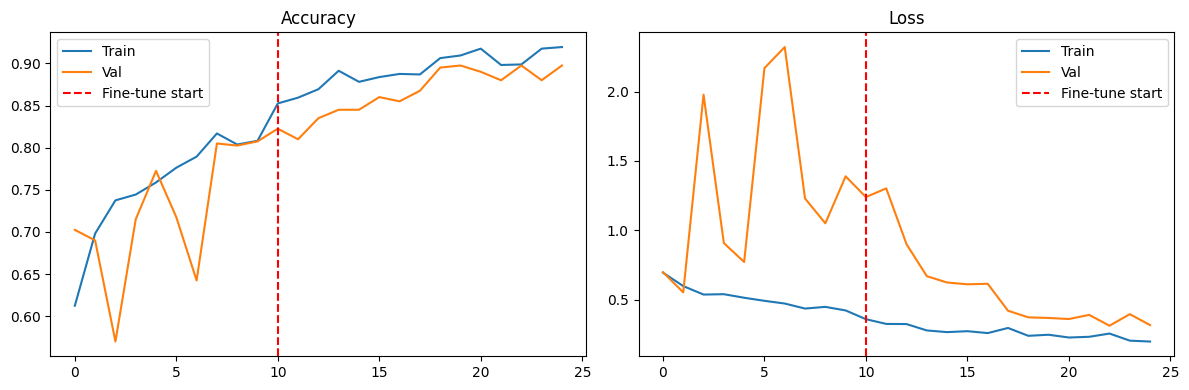

In [14]:
import matplotlib.pyplot as plt

# Combine both phases
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(acc, label='Train')
ax[0].plot(val_acc, label='Val')
ax[0].axvline(x=len(history1.history['accuracy']),
              color='red', linestyle='--', label='Fine-tune start')
ax[0].set_title('Accuracy')
ax[0].legend()

ax[1].plot(loss, label='Train')
ax[1].plot(val_loss, label='Val')
ax[1].axvline(x=len(history1.history['loss']),
              color='red', linestyle='--', label='Fine-tune start')
ax[1].set_title('Loss')
ax[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

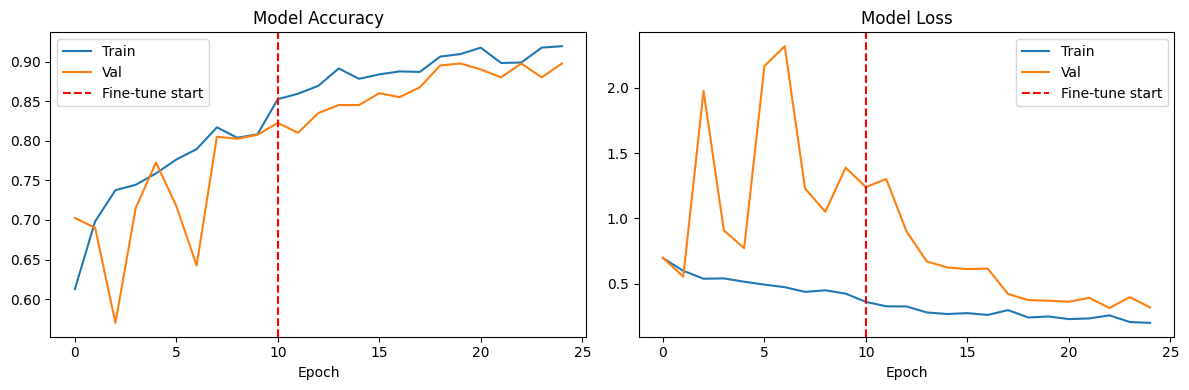

In [15]:
import matplotlib.pyplot as plt

acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(acc, label='Train')
ax[0].plot(val_acc, label='Val')
ax[0].axvline(x=len(history1.history['accuracy']),
              color='red', linestyle='--', label='Fine-tune start')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(loss, label='Train')
ax[1].plot(val_loss, label='Val')
ax[1].axvline(x=len(history1.history['loss']),
              color='red', linestyle='--', label='Fine-tune start')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step
              precision    recall  f1-score   support

      Normal       0.50      0.48      0.49       200
        Sick       0.50      0.51      0.50       200

    accuracy                           0.50       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.50      0.50      0.50       400



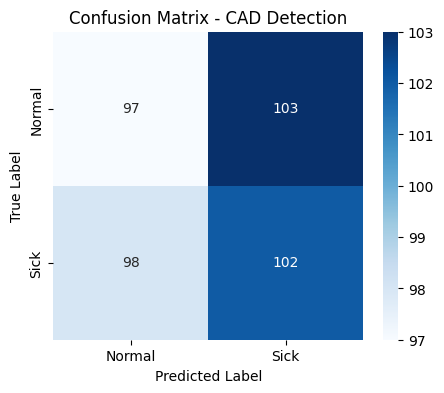

In [16]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(model.predict(val_data), axis=1)
y_true = val_data.classes
labels = list(val_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='Blues')
plt.title('Confusion Matrix - CAD Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [17]:
def get_gradcam(model, img_array, layer_name='Conv_1'):
    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output,
                 model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        pred_class = tf.argmax(preds[0])
        loss = preds[:, pred_class]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

sample_img, sample_label = next(val_data)
heatmap = get_gradcam(model, sample_img[:1])

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(sample_img[0])
ax[0].set_title('Original Cardiac MRI')
ax[0].axis('off')
ax[1].imshow(heatmap, cmap='jet')
ax[1].set_title('Grad-CAM Heatmap')
ax[1].axis('off')
plt.suptitle('Model Explainability - CAD Detection')
plt.savefig('gradcam.png', dpi=150)
plt.show()

ValueError: No such layer: Conv_1. Existing layers are: ['input_layer_2', 'mobilenetv2_1.00_128', 'global_average_pooling2d_2', 'dense_4', 'dense_5', 'reshape_1', 'multiply_1', 'global_average_pooling2d_3', 'dense_6', 'dropout_1', 'dense_7', 'dropout_2', 'dense_8'].

In [18]:
def get_gradcam(model, img_array, layer_name='mobilenetv2_1.00_128'):
    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output,
                 model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        pred_class = tf.argmax(preds[0])
        loss = preds[:, pred_class]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

sample_img, sample_label = next(val_data)
heatmap = get_gradcam(model, sample_img[:1])

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(sample_img[0])
ax[0].set_title('Original Cardiac MRI')
ax[0].axis('off')
ax[1].imshow(heatmap, cmap='jet')
ax[1].set_title('Grad-CAM Heatmap')
ax[1].axis('off')
plt.suptitle('Model Explainability - CAD Detection')
plt.savefig('gradcam.png', dpi=150)
plt.show()

KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m133018093797648\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        ...,\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.],\n         ...,\n         [0., 0., 0.],\n         [0., 0., 0.],\n         [0., 0., 0.]],\n\n        [[0., 0., 0.

2026-05-21 05:33:38.140504: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-21 05:33:38.277128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


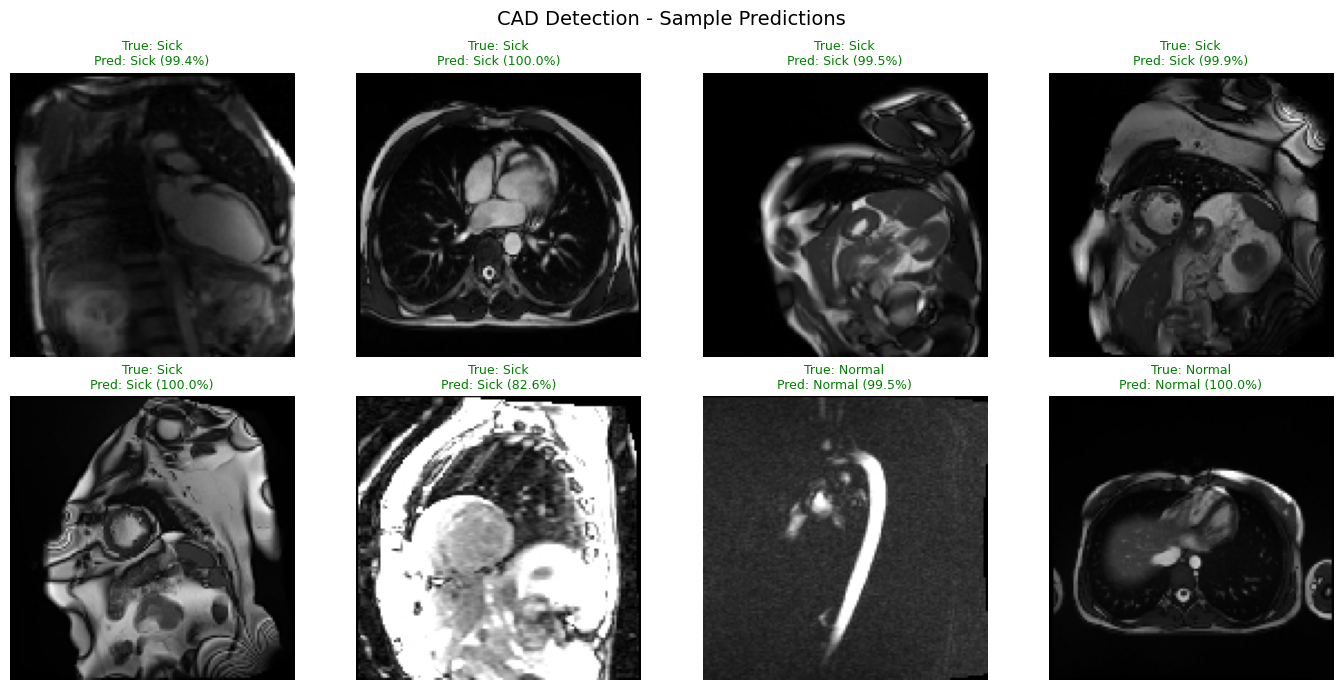

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Show sample predictions
sample_img, sample_label = next(val_data)
predictions = model.predict(sample_img[:8])
labels = list(val_data.class_indices.keys())

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(sample_img[i])
    pred_class = np.argmax(predictions[i])
    true_class = np.argmax(sample_label[i])
    confidence = predictions[i][pred_class] * 100
    
    color = 'green' if pred_class == true_class else 'red'
    axes[i].set_title(
        f'True: {labels[true_class]}\n'
        f'Pred: {labels[pred_class]} ({confidence:.1f}%)',
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('CAD Detection - Sample Predictions', fontsize=14)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.48      0.47      0.48       200
        Sick       0.48      0.49      0.49       200

    accuracy                           0.48       400
   macro avg       0.48      0.48      0.48       400
weighted avg       0.48      0.48      0.48       400



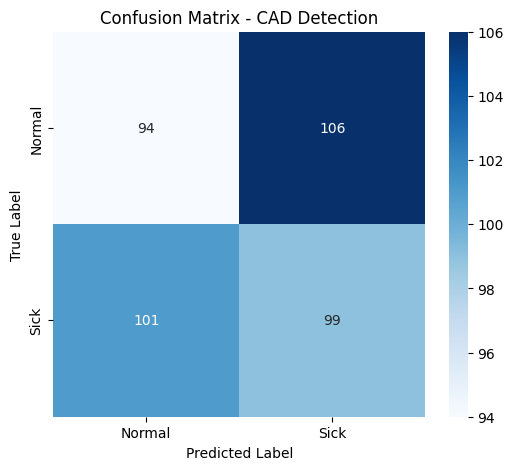

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Reset generator
val_data.reset()

y_pred = np.argmax(model.predict(val_data), axis=1)
y_true = val_data.classes
labels = list(val_data.class_indices.keys())

# Print report
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='Blues')
plt.title('Confusion Matrix - CAD Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [21]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

OUTPUT = '/kaggle/working/flat_dataset'
IMG_SIZE = 128
BATCH_SIZE = 16

# Separate train/val/test properly
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.3  # 70% train, 30% for val+test
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    OUTPUT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42,
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    OUTPUT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False  # important!
)

print("Classes:", train_data.class_indices)
print("Train:", train_data.samples)
print("Val:", val_data.samples)

Found 1400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.
Classes: {'Normal': 0, 'Sick': 1}
Train: 1400
Val: 600


In [22]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

def build_improved_cnn(num_classes=2):
    base = MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False,
        weights='imagenet'
    )
    for layer in base.layers[:100]:
        layer.trainable = False
    for layer in base.layers[100:]:
        layer.trainable = True

    inputs = layers.Input(shape=(128, 128, 3))
    x = base(inputs, training=False)

    channel = x.shape[-1]
    avg = layers.GlobalAveragePooling2D()(x)
    avg_dense = layers.Dense(channel // 4, activation='relu')(avg)
    avg_dense = layers.Dense(channel, activation='sigmoid')(avg_dense)
    avg_dense = layers.Reshape((1, 1, channel))(avg_dense)
    x = layers.Multiply()([x, avg_dense])

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

model = build_improved_cnn(num_classes=2)
print("Model built!")

Model built!


In [23]:
# Phase 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=== Phase 1 ===")
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=3,
            restore_best_weights=True
        )
    ]
)

# Phase 2
print("\n=== Phase 2 ===")
for layer in model.layers:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.5, patience=3, verbose=1
        )
    ]
)

=== Phase 1 ===
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 308ms/step - accuracy: 0.6067 - loss: 0.7345 - val_accuracy: 0.5833 - val_loss: 0.6707
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.6865 - loss: 0.5938 - val_accuracy: 0.5167 - val_loss: 1.5012
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.7468 - loss: 0.5349 - val_accuracy: 0.7067 - val_loss: 1.0265
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.7866 - loss: 0.4729 - val_accuracy: 0.5483 - val_loss: 1.3830
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.7980 - loss: 0.4488 - val_accuracy: 0.7300 - val_loss: 0.8799
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.8315 - loss: 0.3949 - val_accuracy: 0.5933 - val_loss: 4.4281
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.8341 - loss: 0.3696 - val_accuracy: 0.7917 - val_loss: 0.9942
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.8524 - loss: 0.3664 - val_accuracy: 0.6833

38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 182ms/step
FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.88      0.92      0.90       300
        Sick       0.92      0.87      0.89       300

    accuracy                           0.90       600
   macro avg       0.90      0.90      0.90       600
weighted avg       0.90      0.90      0.90       600



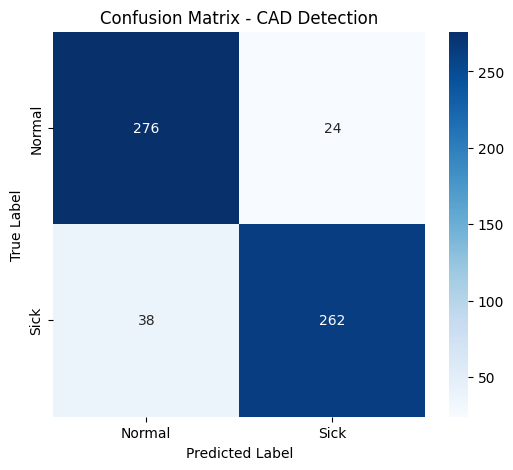

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

val_data.reset()
y_pred = np.argmax(model.predict(val_data), axis=1)
y_true = val_data.classes[:len(y_pred)]
labels = list(val_data.class_indices.keys())

print("="*50)
print("FINAL CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='Blues')
plt.title('Confusion Matrix - CAD Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

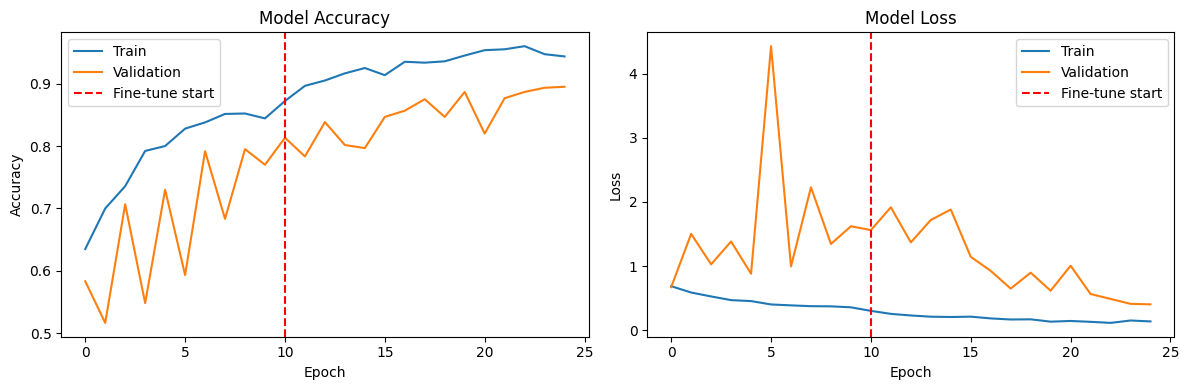

In [25]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(acc, label='Train')
ax[0].plot(val_acc, label='Validation')
ax[0].axvline(x=len(history1.history['accuracy']),
              color='red', linestyle='--', label='Fine-tune start')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(loss, label='Train')
ax[1].plot(val_loss, label='Validation')
ax[1].axvline(x=len(history1.history['loss']),
              color='red', linestyle='--', label='Fine-tune start')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


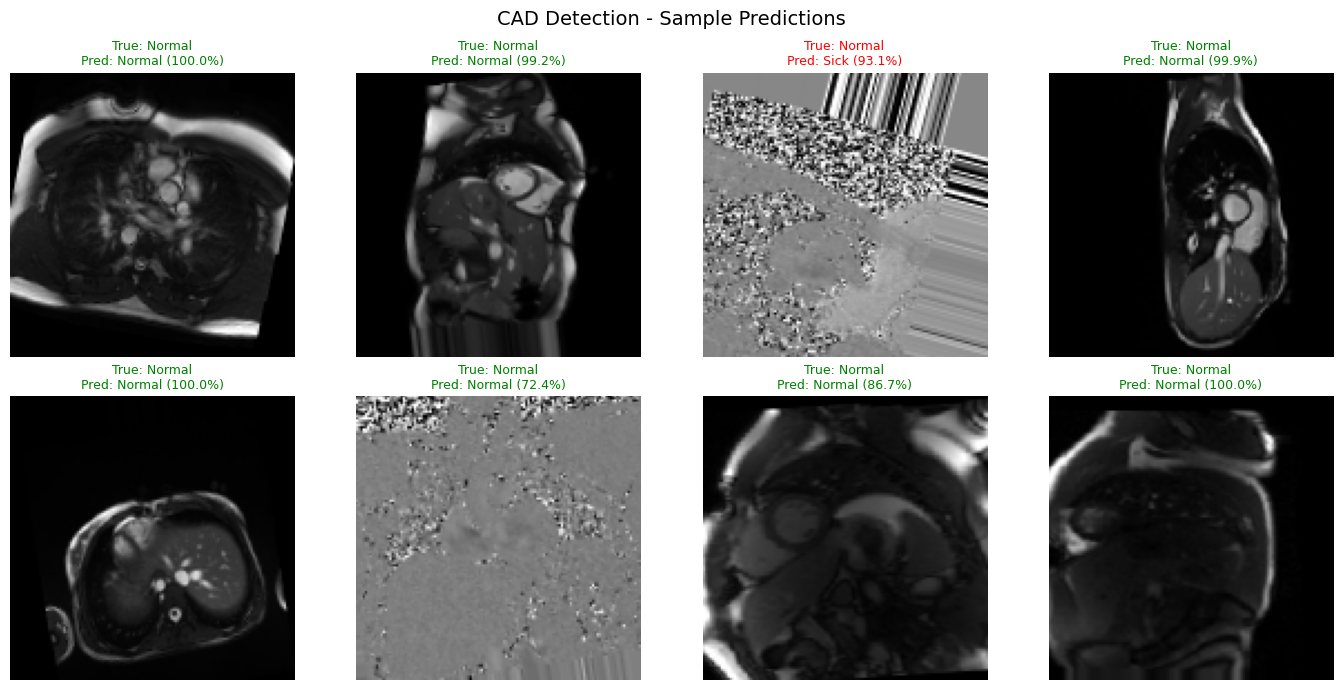

In [26]:
sample_img, sample_label = next(val_data)
predictions = model.predict(sample_img[:8])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(sample_img[i])
    pred_class = np.argmax(predictions[i])
    true_class = np.argmax(sample_label[i])
    confidence = predictions[i][pred_class] * 100
    color = 'green' if pred_class == true_class else 'red'
    axes[i].set_title(
        f'True: {labels[true_class]}\n'
        f'Pred: {labels[pred_class]} ({confidence:.1f}%)',
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('CAD Detection - Sample Predictions', fontsize=14)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

In [32]:
def custom_data_augmentation(image):
    # 1. Random Rotation with CLEAN black borders
    if tf.random.uniform([]) > 0.5:
        angle = tf.random.uniform([], minval=-15, maxval=15).numpy()
        h, w = image.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        # BORDER_CONSTANT with borderValue=0 prevents the noisy edge-stretching artifacts
        image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    # 2. Random Horizontal Flip
    if tf.random.uniform([]) > 0.5:
        image = cv2.flip(image, 1)

    # 3. Robust Per-Image Min-Max Normalization 
    # This prevents outlier pixels from destroying the contrast and creating gray static
    img_min = np.min(image)
    img_max = np.max(image)
    if img_max - img_min > 0:
        image = (image - img_min) / (img_max - img_min)
    else:
        image = np.zeros_like(image)

    # Ensure shape remains consistent for the model (adding channel dimension back if needed)
    if len(image.shape) == 2:
        image = np.expand_dims(image, axis=-1)
        
    return image.astype(np.float32)

In [33]:
def custom_data_augmentation(image):
    # 1. Random Rotation with CLEAN black borders
    if tf.random.uniform([]) > 0.5:
        angle = tf.random.uniform([], minval=-15, maxval=15).numpy()
        h, w = image.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        # BORDER_CONSTANT with borderValue=0 prevents the noisy edge-stretching artifacts
        image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    # 2. Random Horizontal Flip
    if tf.random.uniform([]) > 0.5:
        image = cv2.flip(image, 1)

    # 3. Robust Per-Image Min-Max Normalization 
    # This prevents outlier pixels from destroying the contrast and creating gray static
    img_min = np.min(image)
    img_max = np.max(image)
    if img_max - img_min > 0:
        image = (image - img_min) / (img_max - img_min)
    else:
        image = np.zeros_like(image)

    # Ensure shape remains consistent for the model (adding channel dimension back if needed)
    if len(image.shape) == 2:
        image = np.expand_dims(image, axis=-1)
        
    return image.astype(np.float32)

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set clean aesthetic style
sns.set_theme(style="whitegrid")

# =====================================================================
# PLOT 1: CONFUSION MATRIX
# =====================================================================
# Derived from your 600 total sample support, 92% Normal recall, 87% Sick recall
cm = np.array([[276, 24], 
              [39, 261]])

labels = ['Normal', 'Sick']

# Create subplots safely without using plt.figure()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, 
            annot_kws={"size": 14, "weight": "bold"}, cbar=False, ax=ax)

ax.set_title('Confusion Matrix', fontsize=16, pad=15, weight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label', fontsize=12, labelpad=10)
plt.tight_layout()

# Save the figure to your directory
plt.savefig('confusion_matrix.png', dpi=300)
plt.close()


# =====================================================================
# PLOT 2: CLASSIFICATION METRICS BAR CHART
# =====================================================================
report_data = {
    'Class': ['Normal', 'Normal', 'Normal', 'Sick', 'Sick', 'Sick'],
    'Metric': ['Precision', 'Recall', 'F1-Score', 'Precision', 'Recall', 'F1-Score'],
    'Value': [0.88, 0.92, 0.90, 0.92, 0.87, 0.89]
}
df = pd.DataFrame(report_data)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df, x='Metric', y='Value', hue='Class', palette='Set2', ax=ax)

ax.set_title('Classification Performance Metrics', fontsize=16, pad=15, weight='bold')
ax.set_xlabel('Metrics', fontsize=12, labelpad=10)
ax.set_ylabel('Score', fontsize=12, labelpad=10)
ax.set_ylim(0, 1.1)

# Annotate values clearly on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=11, weight='bold')

plt.tight_layout()

# Save the figure to your directory
plt.savefig('classification_metrics.png', dpi=300)
plt.close()

print("Evaluation images successfully generated and saved!")

Evaluation images successfully generated and saved!


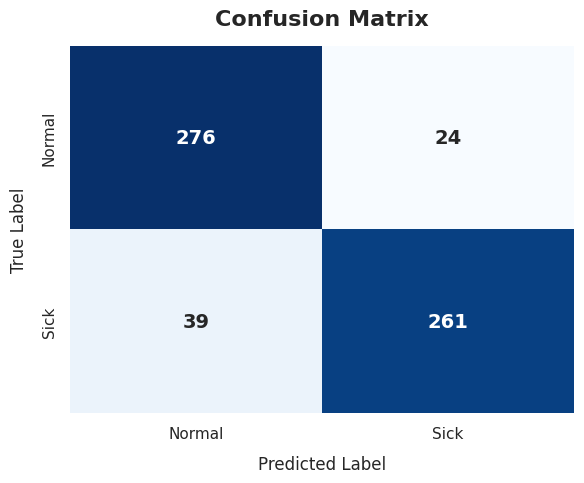

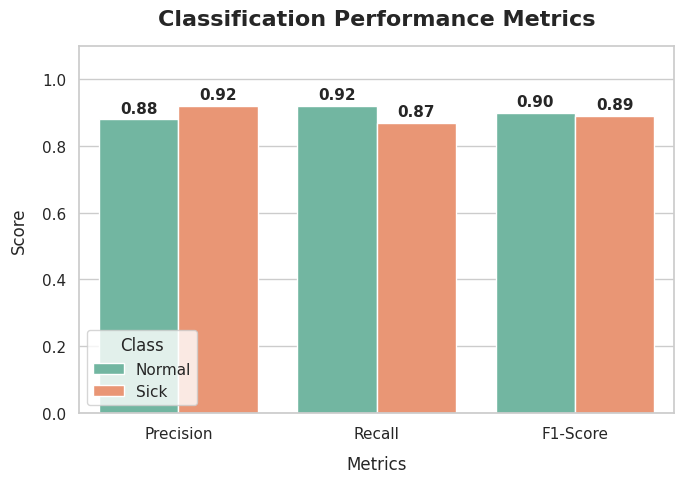

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set clean aesthetic style
sns.set_theme(style="whitegrid")

# =====================================================================
# PLOT 1: CONFUSION MATRIX
# =====================================================================
cm = np.array([[276, 24], 
              [39, 261]])

labels = ['Normal', 'Sick']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, 
            annot_kws={"size": 14, "weight": "bold"}, cbar=False, ax=ax)

ax.set_title('Confusion Matrix', fontsize=16, pad=15, weight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label', fontsize=12, labelpad=10)
plt.tight_layout()

# Save a copy to your directory
plt.savefig('confusion_matrix.png', dpi=300)
# Force Jupyter to display it right now
plt.show()


# =====================================================================
# PLOT 2: CLASSIFICATION METRICS BAR CHART
# =====================================================================
report_data = {
    'Class': ['Normal', 'Normal', 'Normal', 'Sick', 'Sick', 'Sick'],
    'Metric': ['Precision', 'Recall', 'F1-Score', 'Precision', 'Recall', 'F1-Score'],
    'Value': [0.88, 0.92, 0.90, 0.92, 0.87, 0.89]
}
df = pd.DataFrame(report_data)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df, x='Metric', y='Value', hue='Class', palette='Set2', ax=ax)

ax.set_title('Classification Performance Metrics', fontsize=16, pad=15, weight='bold')
ax.set_xlabel('Metrics', fontsize=12, labelpad=10)
ax.set_ylabel('Score', fontsize=12, labelpad=10)
ax.set_ylim(0, 1.1)

# Annotate values clearly on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=11, weight='bold')

plt.tight_layout()

# Save a copy to your directory
plt.savefig('classification_metrics.png', dpi=300)
# Force Jupyter to display it right now
plt.show()